In [20]:
import h5py
import numpy as np

# Change this to whichever file you want to inspect first
FILE = "3d_1400.hdf5"

def print_structure(name, obj):
    indent = "  " * name.count("/")
    if isinstance(obj, h5py.Dataset):
        print(f"{indent}{name}  →  shape={obj.shape}  dtype={obj.dtype}")
    else:
        print(f"{indent}{name}/")

with h5py.File(FILE, "r") as f:
    print(f"=== Structure of {FILE} ===\n")
    f.visititems(print_structure)

    print("\n=== Top-level keys ===")
    print(list(f.keys()))

    print("\n=== Top-level attributes ===")
    for k, v in f.attrs.items():
        print(f"  {k}: {v}")

=== Structure of 3d_1400.hdf5 ===

data  →  shape=(5000, 3600)  dtype=float64
params  →  shape=(5000, 4)  dtype=float64

=== Top-level keys ===
['data', 'params']

=== Top-level attributes ===


data: min=0.0003  max=0.2578  mean=0.0131
params: min=0.0263  max=359.9759  mean=81.5150


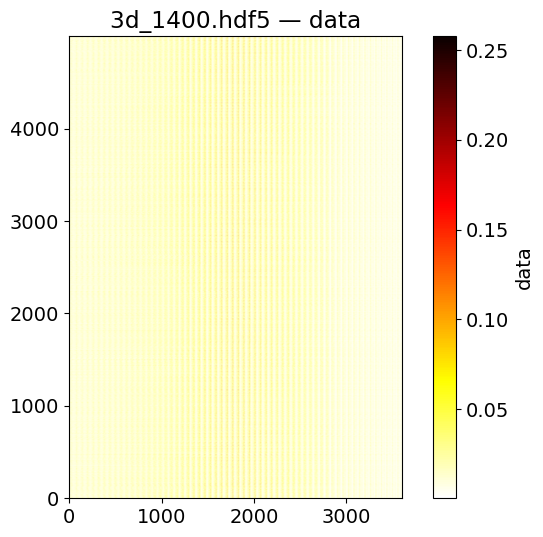

In [21]:
FILE = "3d_1400.hdf5"

with h5py.File(FILE, "r") as f:

    # Print min/max/mean for every dataset so you know value ranges
    def summarize(name, obj):
        if isinstance(obj, h5py.Dataset):
            arr = obj[()]
            print(f"{name}: min={arr.min():.4f}  max={arr.max():.4f}  mean={arr.mean():.4f}")
    f.visititems(summarize)

    # Quick plot — replace 'pgv' with whatever key the structure reveals
    # e.g. f['pgv'], f['ground_motion'], f['data'] etc.
    key = list(f.keys())[0]
    arr = f[key][()]

    if arr.ndim == 2:
        plt.figure(figsize=(8, 6))
        plt.imshow(arr, origin="lower", cmap="hot_r")
        plt.colorbar(label=key)
        plt.title(f"{FILE} — {key}")
        plt.show()
    elif arr.ndim == 3:
        # Likely (n_events, lat, lon) or (lat, lon, components)
        plt.figure(figsize=(8, 6))
        plt.imshow(arr[0], origin="lower", cmap="hot_r")
        plt.colorbar(label=f"{key}[0]")
        plt.title(f"{FILE} — {key}, slice 0")
        plt.show()

params — min/max per column:
  col 0: min=2.0000  max=19.9956
  col 1: min=0.0307  max=359.9759
  col 2: min=0.0263  max=89.9975
  col 3: min=0.0289  max=179.9647

data — min=0.0003  max=0.2578  mean=0.0131
data — any negative? False


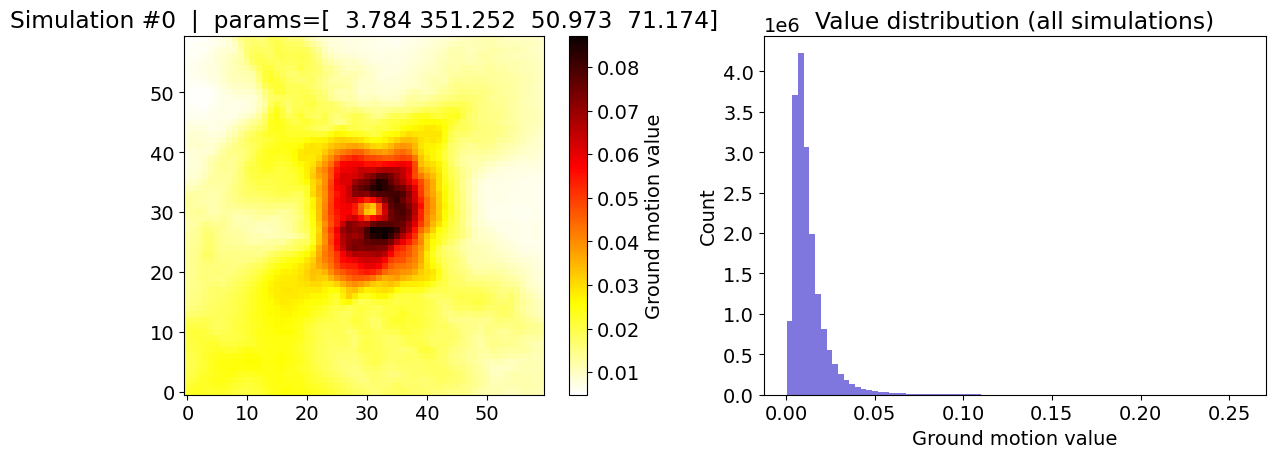


3600 factors: [1, 2, 3, 4, 5, 6, 8, 9, 10, 12, 15, 16, 18, 20, 24, 25, 30, 36, 40, 45, 48, 50, 60, 72, 75, 80, 90, 100]
Most likely grid: 60x60


In [22]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

FILE = "3d_1400.hdf5"

with h5py.File(FILE, "r") as f:
    data   = f["data"][()]    # (5000, 3600)
    params = f["params"][()]  # (5000, 4)

# ── 1. Inspect params columns ──────────────────────────────────────────
print("params — min/max per column:")
for i in range(params.shape[1]):
    print(f"  col {i}: min={params[:,i].min():.4f}  max={params[:,i].max():.4f}")

# ── 2. Inspect data values ─────────────────────────────────────────────
print(f"\ndata — min={data.min():.4f}  max={data.max():.4f}  mean={data.mean():.4f}")
print(f"data — any negative? {(data < 0).any()}")

# ── 3. Reshape one simulation's map and plot it ────────────────────────
# 3600 = 60x60 grid — try reshaping to (60, 60)
grid_side = int(np.sqrt(data.shape[1]))  # 60
sample_idx = 0                             # change to any 0–4999

pgv_map = data[sample_idx].reshape(grid_side, grid_side)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw map
im = axes[0].imshow(pgv_map, origin="lower", cmap="hot_r")
plt.colorbar(im, ax=axes[0], label="Ground motion value")
axes[0].set_title(f"Simulation #{sample_idx}  |  params={params[sample_idx].round(3)}")

# Distribution of values across all 5000 simulations
axes[1].hist(data.flatten(), bins=80, color="#7f77dd", edgecolor="none")
axes[1].set_xlabel("Ground motion value")
axes[1].set_ylabel("Count")
axes[1].set_title("Value distribution (all simulations)")

plt.tight_layout()
plt.show()

# ── 4. Check if reshape is actually 60x60 or something else ───────────
print(f"\n3600 factors: {[i for i in range(1,3601) if 3600%i==0 and i<=100]}")
print("Most likely grid: 60x60")

Train: 3500  Val: 750  Test: 750


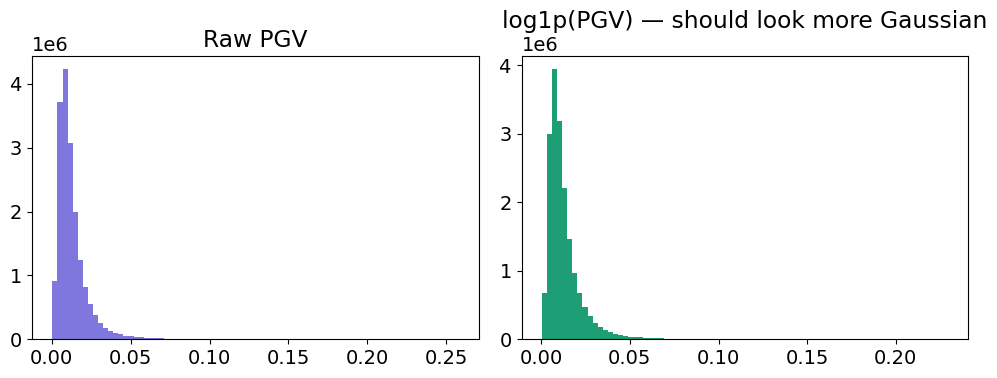

In [23]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FILE = "3d_1400.hdf5"

with h5py.File(FILE, "r") as f:
    data   = f["data"][()]    # (5000, 3600) — PGV maps, flattened
    params = f["params"][()]  # (5000, 4)   — strike, dip, rake, magnitude

# Label the columns based on what we saw
param_names = ["magnitude", "strike", "dip", "rake"]

# Log-transform data — PGV is log-normally distributed
# Add small epsilon to avoid log(0)
data_log = np.log1p(data)  # log(1 + x), safe for zeros

# Normalize params (zero mean, unit variance)
scaler = StandardScaler()
params_scaled = scaler.fit_transform(params)

# Train / val / test split  (70 / 15 / 15)
X_train, X_temp, y_train, y_temp = train_test_split(
    params_scaled, data_log, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}")
# → Train: 3500  Val: 750  Test: 750

# ── Quick sanity check: does log transform help? ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(data.flatten(), bins=80, color="#7f77dd")
axes[0].set_title("Raw PGV")
axes[1].hist(data_log.flatten(), bins=80, color="#1d9e75")
axes[1].set_title("log1p(PGV) — should look more Gaussian")
plt.tight_layout(); plt.show()